In [1]:
from pathlib import Path
import pandas as pd

In [2]:
DATA_DIR = Path('/data/OmniAnomaly/ServerMachineDataset')

In [3]:
train = pd.read_csv(
    DATA_DIR / "train" / "machine-1-1.txt",
    header=None
)

train.head()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
0,0.032258,0.039195,0.027871,0.024390,0.0,0.915385,0.343691,0.0,0.020011,0.000122,...,0.0,0.004298,0.029993,0.022131,0.0,0.000045,0.034677,0.034747,0.0,0.0
1,0.043011,0.048729,0.033445,0.025552,0.0,0.915385,0.344633,0.0,0.019160,0.001722,...,0.0,0.004298,0.030041,0.028821,0.0,0.000045,0.035763,0.035833,0.0,0.0
2,0.043011,0.034958,0.032330,0.025552,0.0,0.915385,0.344633,0.0,0.020011,0.000122,...,0.0,0.004298,0.026248,0.021101,0.0,0.000045,0.033012,0.033082,0.0,0.0
3,0.032258,0.028602,0.030100,0.024390,0.0,0.912821,0.342750,0.0,0.021289,0.000000,...,0.0,0.004298,0.030169,0.025733,0.0,0.000022,0.035112,0.035182,0.0,0.0
4,0.032258,0.019068,0.026756,0.023229,0.0,0.912821,0.342750,0.0,0.018734,0.000000,...,0.0,0.004298,0.027240,0.022645,0.0,0.000034,0.033447,0.033517,0.0,0.0


In [4]:
train.shape

(28479, 38)

In [5]:
train.describe()

,0,1,2,3,4,5,6,7,8,9,...,28,29,30,31,32,33,34,35,36,37
count,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,28479.0,28479.000000,28479.000000,...,28479.0,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.000000,28479.0,28479.0
mean,0.064195,0.056882,0.053549,0.050188,0.0,0.913552,0.262274,0.0,0.020346,0.000159,...,0.0,0.005501,0.047294,0.036172,0.000188,0.000033,0.050351,0.050401,0.0,0.0
std,0.056685,0.042516,0.037695,0.037443,0.0,0.037972,0.066661,0.0,0.009982,0.001287,...,0.0,0.002545,0.033065,0.023716,0.000201,0.000015,0.035048,0.035044,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,...,0.0,0.000000,0.006146,0.006691,0.000000,0.000000,0.008760,0.008759,0.0,0.0
25%,0.032258,0.027542,0.027871,0.024390,0.0,0.907692,0.251412,0.0,0.012347,0.000000,...,0.0,0.004298,0.026128,0.021101,0.000000,0.000022,0.027945,0.028015,0.0,0.0
50%,0.043011,0.045551,0.042363,0.037166,0.0,0.912821,0.274011,0.0,0.021005,0.000000,...,0.0,0.004298,0.034858,0.027792,0.000000,0.000034,0.036415,0.036485,0.0,0.0
75%,0.086022,0.075212,0.070234,0.067364,0.0,0.920513,0.311676,0.0,0.027959,0.000122,...,0.0,0.007163,0.062250,0.044261,0.000386,0.000045,0.066025,0.066020,0.0,0.0
max,0.494624,0.421610,0.278707,0.250871,0.0,1.000000,0.360640,0.0,0.118081,0.140435,...,0.0,0.028653,0.275407,0.303139,0.002318,0.001271,0.311229,0.311206,0.0,0.0


In [6]:
labels = pd.read_csv(DATA_DIR / "test_label" / "machine-1-1.txt", header=None)

In [7]:
labels.shape

(28479, 1)

In [8]:
labels.value_counts()

0
0    25785
1     2694
Name: count, dtype: int64

In [9]:
count_normal = (labels[0] == 0).sum()
count_anomaly = (labels[0] == 1).sum()
total = len(labels)

print("Normal:", count_normal)
print("Anomaly:", count_anomaly)
print("Total:", total)
print("Anomaly %:", round(count_anomaly / total * 100, 2))

Normal: 25785
Anomaly: 2694
Total: 28479
Anomaly %: 9.46


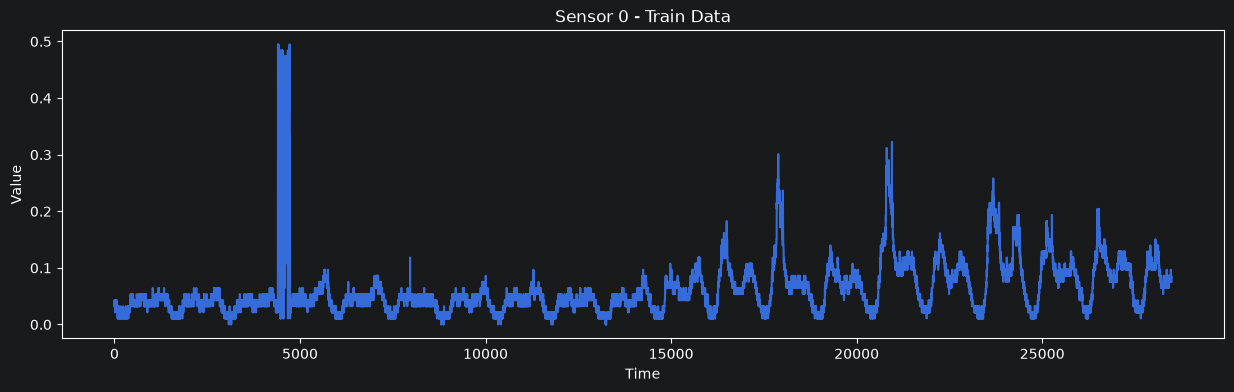

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 4))
plt.plot(train.iloc[:, 0])
plt.title("Sensor 0 - Train Data")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

In [11]:
test = pd.read_csv(
    DATA_DIR / "test" / "machine-1-1.txt",
    header=None
)

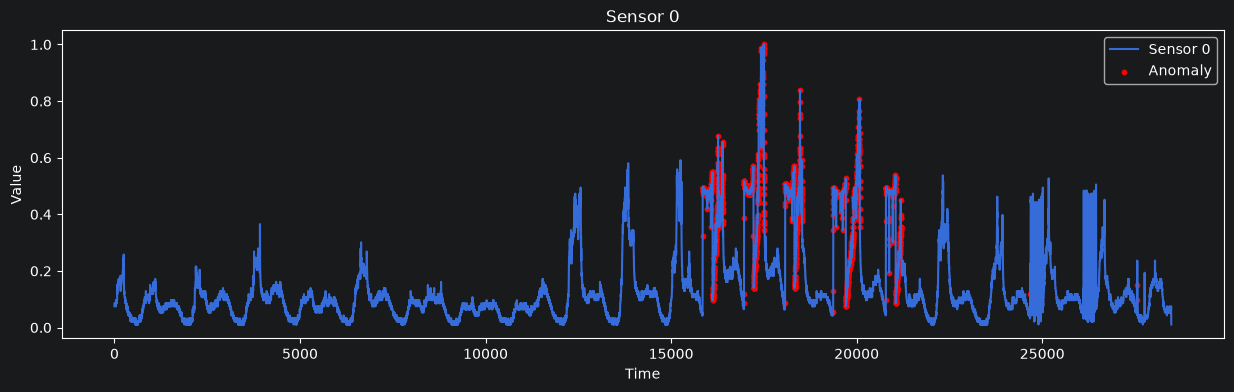

In [12]:
sensor_idx = 0

plt.figure(figsize=(15, 4))

plt.plot(test.iloc[:, sensor_idx], label="Sensor 0")

anomaly_idx = labels[labels[0] == 1].index

plt.scatter(
    anomaly_idx,
    test.iloc[anomaly_idx, sensor_idx],
    color="r",
    s=10,
    label="Anomaly",
)

plt.title(f"Sensor {sensor_idx}")
plt.xlabel("Time")
plt.ylabel("Value")
plt.legend()
plt.show()


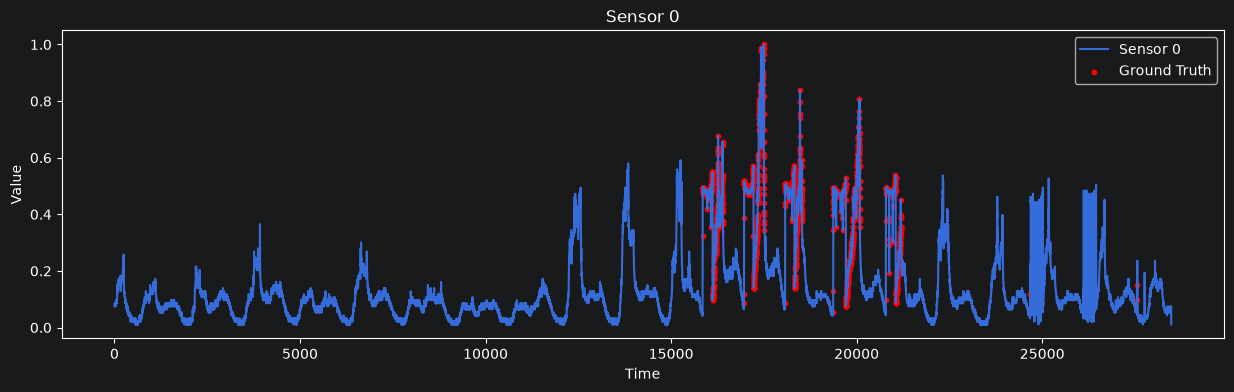

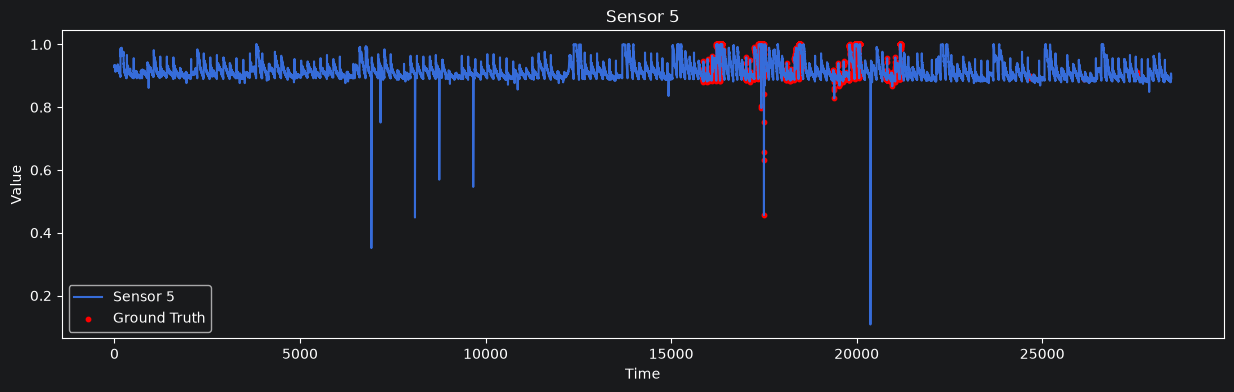

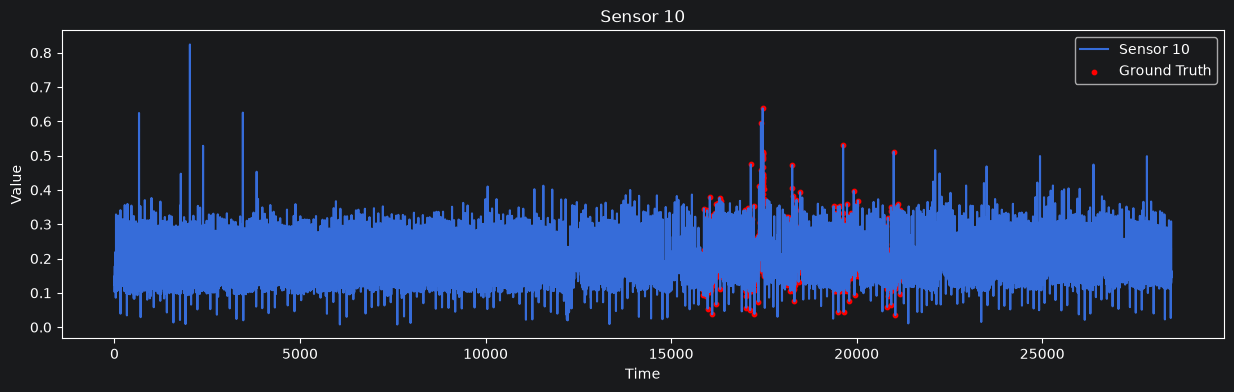

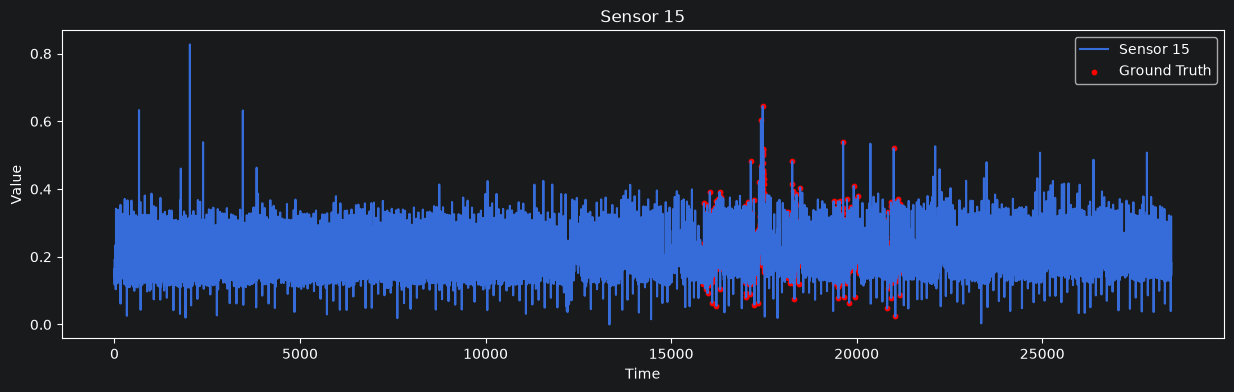

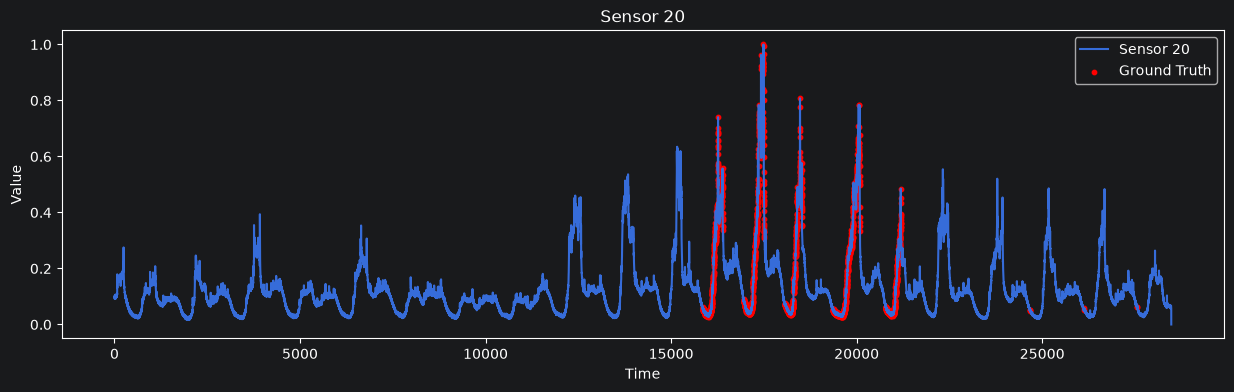

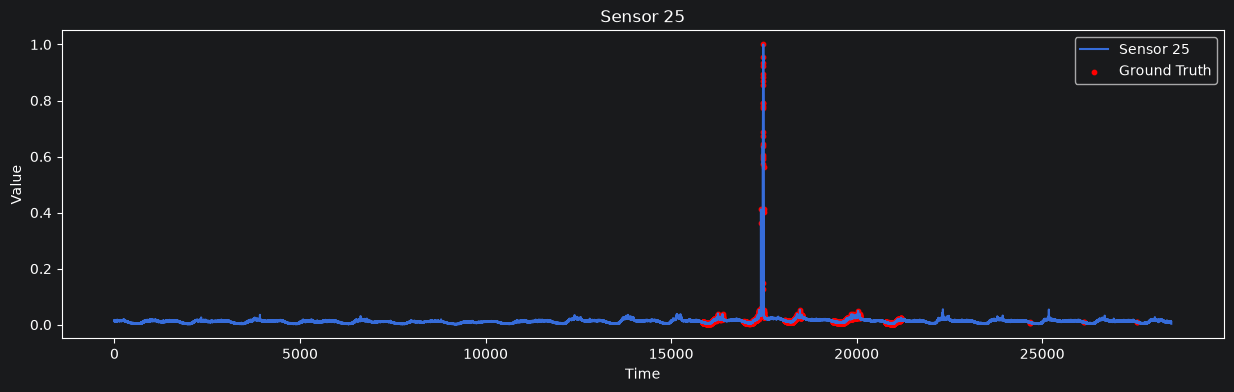

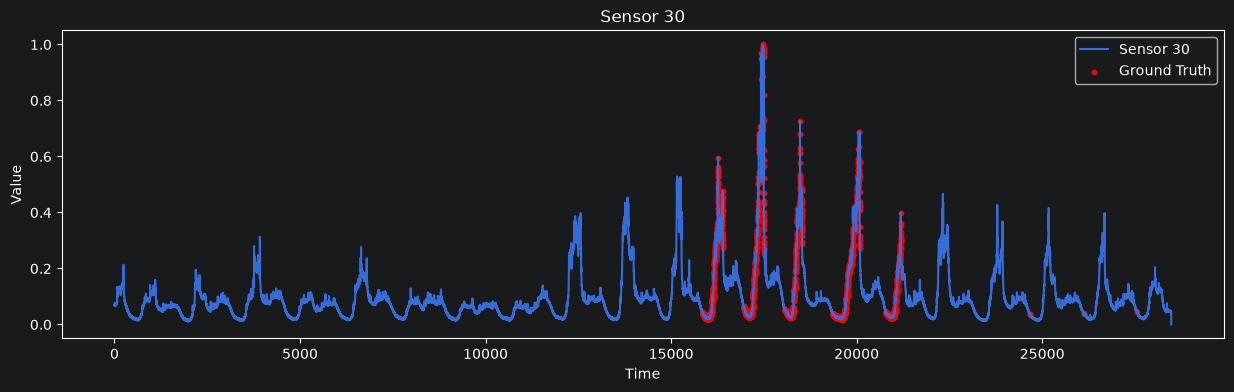

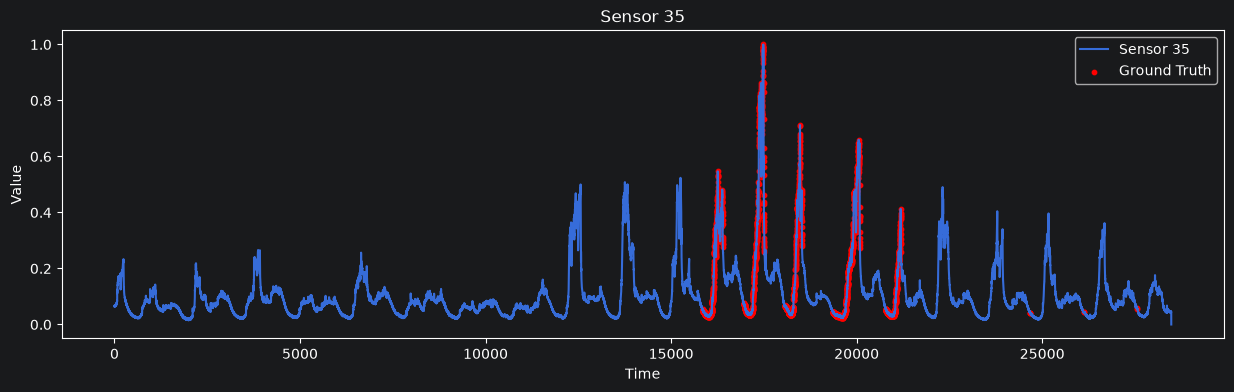

In [13]:
sensors = [0, 5, 10, 15, 20, 25, 30, 35]

for sensor_idx in sensors:
    plt.figure(figsize=(15, 4))
    plt.plot(test.iloc[:, sensor_idx], label=f"Sensor {sensor_idx}")
    anomaly_idx = labels[labels[0] == 1].index
    plt.scatter(
        anomaly_idx,
        test.iloc[anomaly_idx, sensor_idx],
        color="r",
        s=10,
        label="Ground Truth"
    )

    plt.title(f"Sensor {sensor_idx}")
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

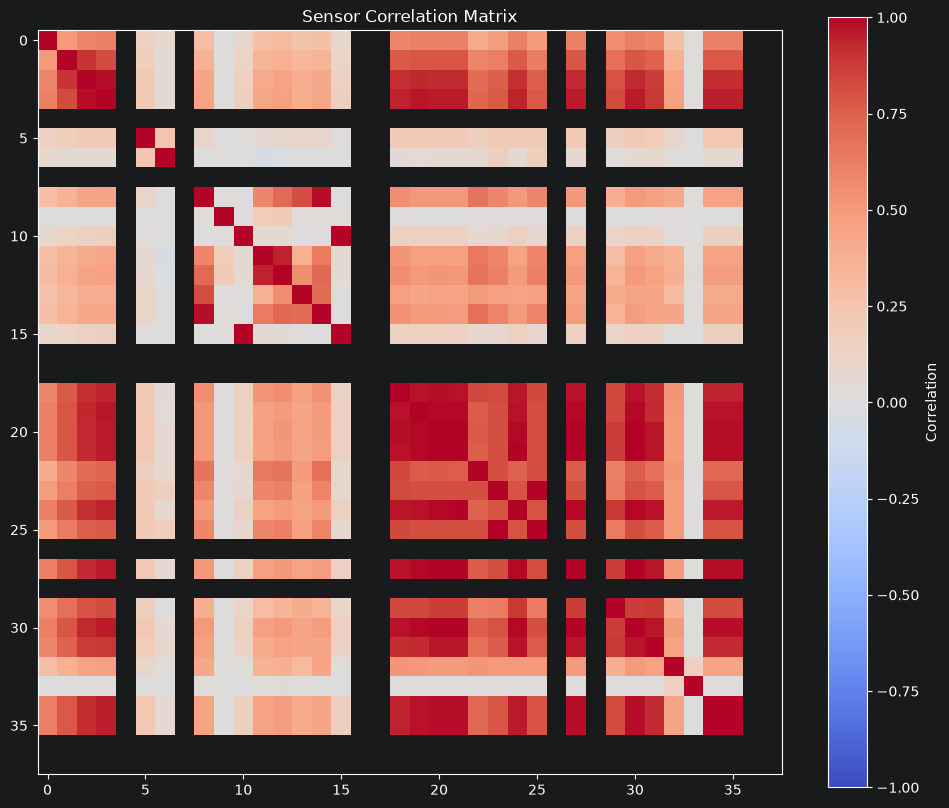

In [14]:
# Correlation Analysis
corr = train.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.title("Sensor Correlation Matrix")
plt.show()



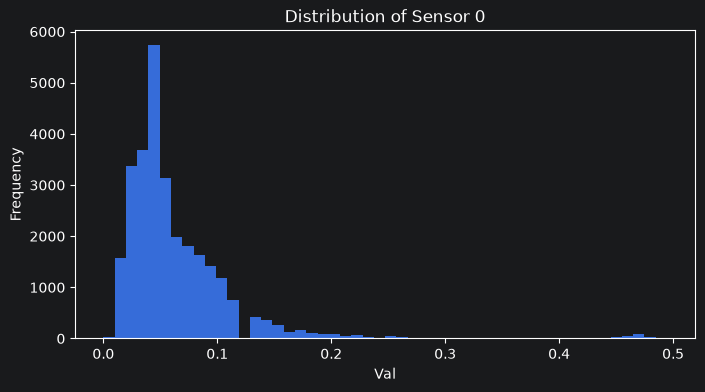

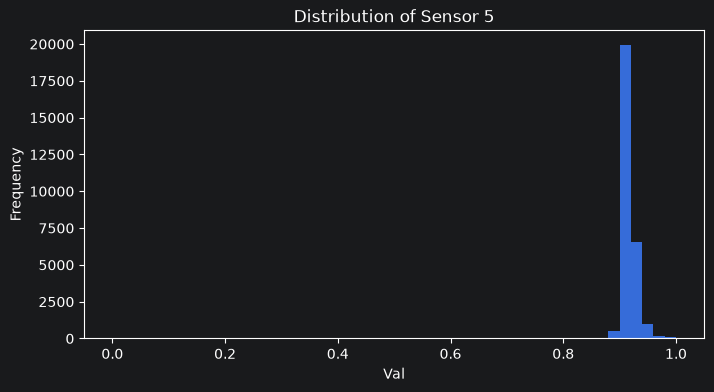

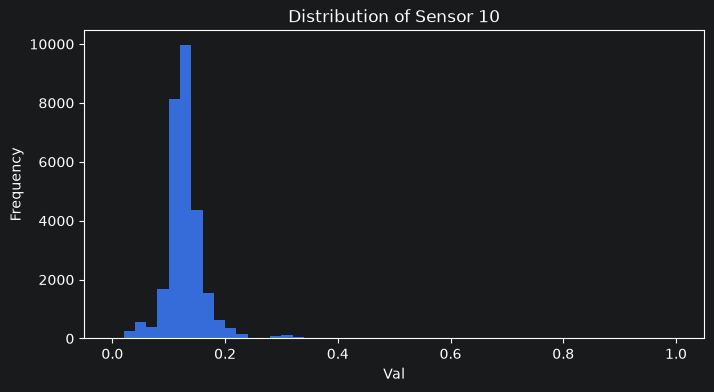

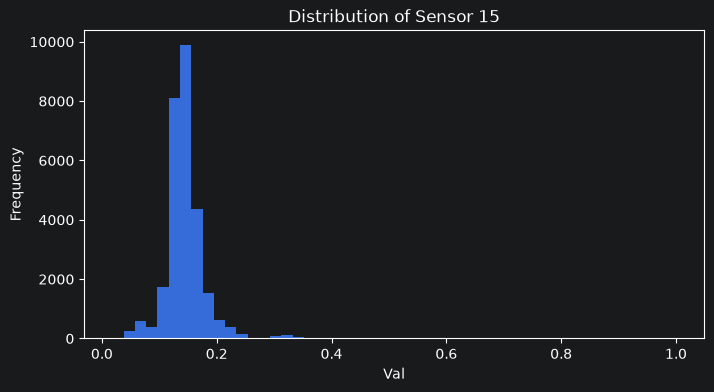

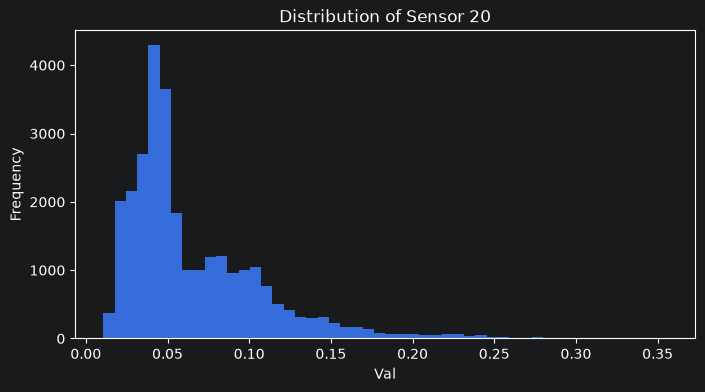

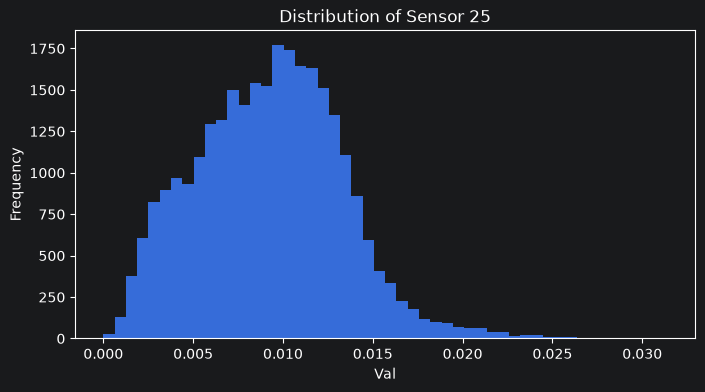

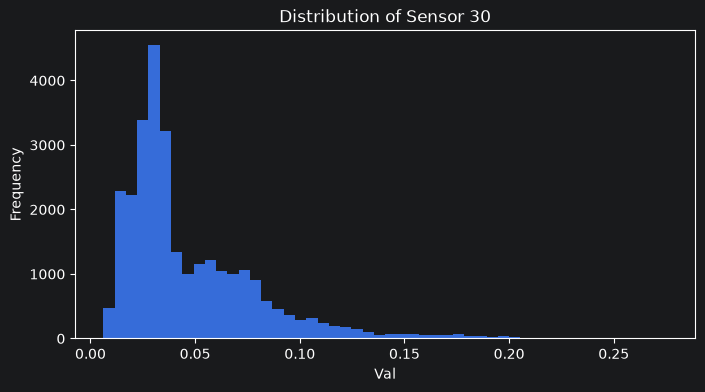

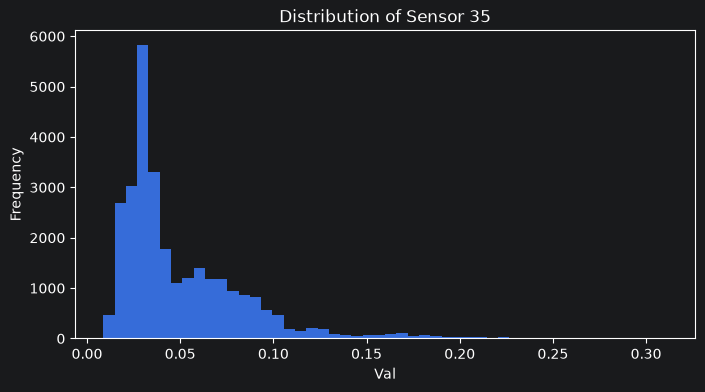

In [20]:
# Distribution of One Sensor
sensors = [0, 5, 10, 15, 20, 25, 30, 35]
for sensor in sensors:
    plt.figure(figsize=(8, 4))
    plt.hist(train.iloc[:, sensor], bins=50)
    plt.title(f"Distribution of Sensor {sensor}")
    plt.xlabel("Val")
    plt.ylabel("Frequency")
    plt.show()